In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
df=pd.read_csv('/kaggle/input/jigsaw-2m-reddit-unlabelled/reddit-removal-log.csv')
df.head()

,body,subreddit
0,You're trying to say arabs aren't native to th...,The_Donald
1,"I am a religious man, science is not what I be...",relationships
2,What the hell? You don't even know this person.,personalfinance
3,but they are kicking people out of their homes...,The_Donald
4,What if she's telling the truth?,relationships


<Axes: >

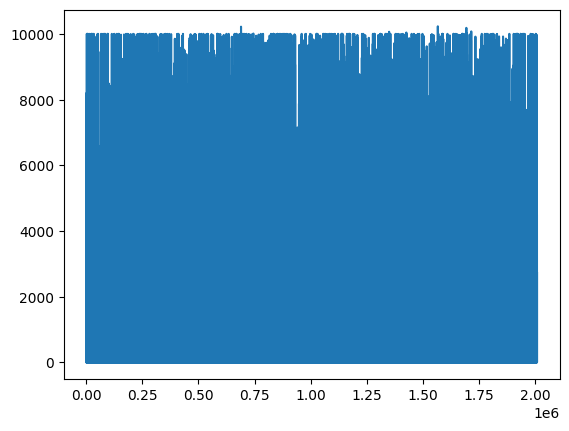

In [2]:
df.body.str.len().plot()

In [3]:
df.subreddit.value_counts()

subreddit
The_Donald          184168
politics            147576
AskReddit           110721
science             105403
worldnews            95026
                     ...  
PurplePillDebate      5852
GetMotivated          5823
asoiaf                5817
NeutralPolitics       5679
jailbreak             5616
Name: count, Length: 100, dtype: int64

In [4]:
traindf= pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/train.csv')
testdf= pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/test.csv')

In [12]:
set(df.negative_example_1) - set(df.body)

{'ADHD',
 'Alzheimers',
 'MachineLearning',
 'addiction',
 'cancer',
 'careerguidance',
 'covidlonghaulers',
 'datingoverthirty',
 'diet',
 'firstworldproblems',
 'happy',
 'offmychest',
 'povertyfinance',
 'relationship_advice'}

In [6]:
df.body[df.body.str.startswith("They don't want you taking",na=False)].tolist()

['They don\'t want you taking Jimmy Jonathan\'s top secret family recipe to Subway, because the secret is that the Mayo they use is sperm, and they know Jared will use it to knock up little girls. Since it\'s Jimmy Jonathan\'s "family" recipe, he\'ll be on the hook for child support, and he might also be considered an accessory to statutory rape.\n']

In [7]:
filtered=traindf[['body','subreddit']][(traindf.rule_violation==1) & traindf.rule.str.startswith('No legal')]

In [8]:
filtered.iloc[500].values

array(["That's when you beat her with jumper cables so she associates it with bad behavior.",
       'aww'], dtype=object)

In [10]:
rulesdf= pd.read_csv('/kaggle/input/popular-subreddit-rules-crawler/subreddits_summary_20250803_133254.csv')
commentsdf= pd.read_csv('/kaggle/input/reddit-example-posts-and-comments/reddit_posts_and_comments.csv')

In [15]:
rulesdf.head()

,name,title,description,public_description,subscribers,created_utc,over18,lang,url,rules_count,moderators_count,crawled_at
0,Futurology,Future(s) Studies,* **[Get a verified flair in r/Futurology](/r/...,A subreddit devoted to the field of Future(s) ...,21564060,2011-12-12T16:05:35,False,en,https://reddit.com/r/Futurology,13,0,2025-08-03T12:41:00.205339
1,pcmasterrace,PC Master Race - PCMR: A place where all enthu...,1. [**Why PC?**](https://pcmasterrace.org/guid...,Welcome to the official subreddit of the PC Ma...,15724831,2011-04-30T23:00:07,False,en,https://reddit.com/r/pcmasterrace,12,0,2025-08-03T12:41:28.608149
2,sex,Sex,r/sex is for civil discussions pertaining to e...,r/sex is for civil discussions pertaining to e...,2743807,2008-01-25T13:51:50,False,en,https://reddit.com/r/sex,12,0,2025-08-03T12:41:39.004070
3,hearthstone,Hearthstone,##[Subreddit Rules](https://www.reddit.com/r/h...,For fans of Blizzard Entertainment's digital c...,1926095,2013-01-18T01:33:00,False,en,https://reddit.com/r/hearthstone,11,0,2025-08-03T12:41:49.463876
4,gifs,GIFs,**GIF links cannot contain sound**\n\n**If the...,"""GIFs"" is officially pronounced with a hard ""J""",21524081,2009-02-14T17:16:47,False,en,https://reddit.com/r/gifs,11,0,2025-08-03T12:41:59.815193


In [11]:
commentsdf

,post_title,post_text,subreddit,post_author,post_url,post_upvotes,post_downvotes,comment_upvotes,comment_downvotes,comment_text,comment_author
0,[D] - NeurIPS'2025 Reviews,"Hey everyone,\n\nNeurIPS 2025 reviews should b...",MachineLearning,Proof-Marsupial-5367,https://www.reddit.com/r/MachineLearning/comme...,203,0,77,0,Friendly reminder that reviews this year are s...,ChoiceStranger2898
1,[D] - NeurIPS'2025 Reviews,"Hey everyone,\n\nNeurIPS 2025 reviews should b...",MachineLearning,Proof-Marsupial-5367,https://www.reddit.com/r/MachineLearning/comme...,203,0,36,0,I had a dream recently where my upcoming avera...,popeldo
2,[D] - NeurIPS'2025 Reviews,"Hey everyone,\n\nNeurIPS 2025 reviews should b...",MachineLearning,Proof-Marsupial-5367,https://www.reddit.com/r/MachineLearning/comme...,203,0,63,0,I will treat the scores as a divine interventi...,matcha-coconut
3,[D] - NeurIPS'2025 Reviews,"Hey everyone,\n\nNeurIPS 2025 reviews should b...",MachineLearning,Proof-Marsupial-5367,https://www.reddit.com/r/MachineLearning/comme...,203,0,33,0,"July 24, so as long as it's July 24 somewhere ...",SmolLM
4,[D] - NeurIPS'2025 Reviews,"Hey everyone,\n\nNeurIPS 2025 reviews should b...",MachineLearning,Proof-Marsupial-5367,https://www.reddit.com/r/MachineLearning/comme...,203,0,34,0,"Well, if you feel heart-broken, be assured tha...",Marionberry6886


In [16]:
set(df.subreddit) - set(rulesdf.name) #removed subreddits

{'Incels', 'The_Donald', 'soccerstreams'}

In [26]:
groupdf=traindf.groupby(['rule','body','subreddit']).filter(lambda group: group['rule_violation'].nunique()>1)

In [43]:
groupdf2=groupdf.groupby(['rule','body','subreddit','rule_violation'],as_index=False).agg({'rule_violation':['count','first'],'row_id':lambda x: list(x)})

In [47]:
groupdf2.columns

MultiIndex([(          'rule',         ''),
            (          'body',         ''),
            (     'subreddit',         ''),
            ('rule_violation',    'count'),
            ('rule_violation',    'first'),
            (        'row_id', '<lambda>')],
           )

In [54]:
for i in sorted(groupdf2.row_id.values,key= lambda x: -len(x[0])):
    print(i)

[list([1806, 1809, 1810, 1811, 1813, 1814, 1816, 1817, 1818, 1819, 1820, 1821, 1823, 1824, 1825, 1826, 1827, 1828])]
[list([1807, 1808, 1812, 1815, 1822])]
[list([1543, 1544])]
[list([781])]
[list([780])]
[list([1870])]
[list([1869])]
[list([272])]
[list([273])]
[list([1104])]
[list([1105])]
[list([1542])]
[list([361])]
[list([362])]


In [ ]:
#1542 -> , 1807, 1808, 1812, 1815, 1822 -> 0; 361,362,1105,1104,272,273,1869,1870,780,781

In [64]:
traindf.loc[traindf['row_id']==1542,'rule_violation']=0
traindf.loc[traindf['row_id'].isin([1807, 1808, 1812, 1815, 1822]),'rule_violation']=1

In [69]:
traindf.drop(index=[361,362,1105,1104,272,273,1869,1870,780,781],inplace=True,)

In [70]:
traindf[traindf['row_id']==1815]

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
1815,1815,www.freekarma.com\n\nFree reddit karma with th...,"No Advertising: Spam, referral links, unsolici...",AskReddit,hungry hole watching for your buddy look her t...,"Chase Sapphire Preferred, spending $4,000 to g...",Stream SD No Mobile Supported [Channel 4 EN](h...,www.freekarma.com\n\nFree reddit karma with th...,1


In [74]:
traindf.groupby(['rule','body','subreddit','rule_violation'],as_index=False)['row_id'] .agg('count')

,rule,body,subreddit,rule_violation,row_id
0,"No Advertising: Spam, referral links, unsolici...","\n\nIf you have some free time on your hands, ...",gifs,1,1
1,"No Advertising: Spam, referral links, unsolici...",\n\nSD | [ English Stream 1 Arsenal vs Tottenh...,soccerstreams,0,1
2,"No Advertising: Spam, referral links, unsolici...",\n\nplease visit http://www.shifadental.net/te...,LifeProTips,1,1
3,"No Advertising: Spam, referral links, unsolici...",\n**HD** ENG [ 1080P HD Amazing] :- [USTREAM E...,soccerstreams,0,1
4,"No Advertising: Spam, referral links, unsolici...",\nFree http://forums.airdroid.com/viewtopic.ph...,soccerstreams,1,1
...,...,...,...,...,...
1928,No legal advice: Do not offer or request legal...,you cant fix her body/brain. i would see how s...,depression,1,1
1929,No legal advice: Do not offer or request legal...,you could always release the sextape to show s...,AskReddit,0,1
1930,No legal advice: Do not offer or request legal...,you could make it out to mr c.a.s.h so I can s...,LifeProTips,0,1
1931,No legal advice: Do not offer or request legal...,you could tell him that the police were asking...,legaladvice,1,1


In [ ]:
traindf.drop_duplicates(['rule','body','subreddit','rule_violation'],inplace=True)

In [ ]:
traindf.shape